### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from matplotlib.colors import ListedColormap

In [2]:
# Load dataset
dataset = pd.read_csv('Social_Network_Ads.csv')

# Encode the Gender column (Male -> 1, Female -> 0)
le = LabelEncoder()
dataset['Gender'] = le.fit_transform(dataset['Gender'])

# Select features including gender
X = dataset[['Gender', 'Age', 'EstimatedSalary']].values
y = dataset['Purchased'].values

In [3]:
X

array([[    1,    19, 19000],
       [    1,    35, 20000],
       [    0,    26, 43000],
       ...,
       [    0,    50, 20000],
       [    1,    36, 33000],
       [    0,    49, 36000]], dtype=int64)

In [4]:
# Scale features (scaling after encoding gender works fine here)
sc = StandardScaler()
X = sc.fit_transform(X)

In [5]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=0)

# Train Logistic Regression model
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [7]:
# Predict on test set
y_pred = classifier.predict(X_test)

=== Evaluation Metrics with Gender ===
Accuracy Score   : 90.00%
Precision Score  : 89.29%
Recall Score     : 78.12%
F1 Score         : 83.33%


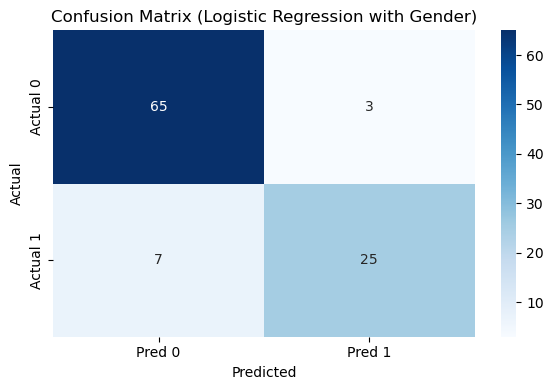

In [8]:
# Evaluation
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Evaluation Metrics with Gender ===")
print(f"Accuracy Score   : {acc * 100:.2f}%")
print(f"Precision Score  : {prec * 100:.2f}%")
print(f"Recall Score     : {rec * 100:.2f}%")
print(f"F1 Score         : {f1 * 100:.2f}%")

# Confusion matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix (Logistic Regression with Gender)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()